In [58]:
import numpy as np
import pandas as pd
import scipy.stats as st 
import seaborn as sns
import matplotlib.pyplot as plt

In [59]:
df_main = pd.read_csv("/content/mxmh_survey_results.csv")
df_main

,Timestamp,Age,Primary streaming service,Hours per day,While working,Instrumentalist,Composer,Fav genre,Exploratory,Foreign languages,...,Frequency [R&B],Frequency [Rap],Frequency [Rock],Frequency [Video game music],Anxiety,Depression,Insomnia,OCD,Music effects,Permissions
0,8/27/2022 19:29:02,18.0,Spotify,3.0,Yes,Yes,Yes,Latin,Yes,Yes,...,Sometimes,Very frequently,Never,Sometimes,3.0,0.0,1.0,0.0,NaN,I understand.
1,8/27/2022 19:57:31,63.0,Pandora,1.5,Yes,No,No,Rock,Yes,No,...,Sometimes,Rarely,Very frequently,Rarely,7.0,2.0,2.0,1.0,NaN,I understand.
2,8/27/2022 21:28:18,18.0,Spotify,4.0,No,No,No,Video game music,No,Yes,...,Never,Rarely,Rarely,Very frequently,7.0,7.0,10.0,2.0,No effect,I understand.
3,8/27/2022 21:40:40,61.0,YouTube Music,2.5,Yes,No,Yes,Jazz,Yes,Yes,...,Sometimes,Never,Never,Never,9.0,7.0,3.0,3.0,Improve,I understand.
4,8/27/2022 21:54:47,18.0,Spotify,4.0,Yes,No,No,R&B,Yes,No,...,Very frequently,Very frequently,Never,Rarely,7.0,2.0,5.0,9.0,Improve,I understand.
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
731,10/30/2022 14:37:28,17.0,Spotify,2.0,Yes,Yes,No,Rock,Yes,Yes,...,Never,Rarely,Very frequently,Never,7.0,6.0,0.0,9.0,Improve,I understand.
732,11/1/2022 22:26:42,18.0,Spotify,1.0,Yes,Yes,No,Pop,Yes,Yes,...,Never,Never,Sometimes,Sometimes,3.0,2.0,2.0,5.0,Improve,I understand.
733,11/3/2022 23:24:38,19.0,Other streaming service,6.0,Yes,No,Yes,Rap,Yes,No,...,Sometimes,Sometimes,Rarely,Rarely,2.0,2.0,2.0,2.0,Improve,I understand.
734,11/4/2022 17:31:47,19.0,Spotify,5.0,Yes,Yes,No,Classical,No,No,...,Never,Never,Never,Sometimes,2.0,3.0,2.0,1.0,Improve,I understand.


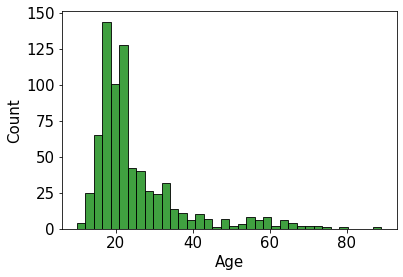

In [60]:
sns.histplot(df_main["Age"],color="green")
plt.show()

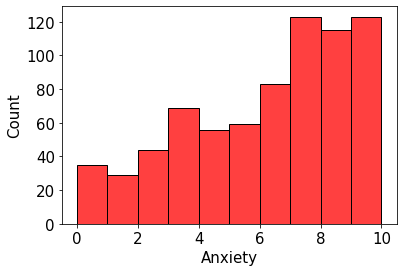

In [61]:
sns.histplot(df_main["Anxiety"],bins=10,color="red")
plt.show()

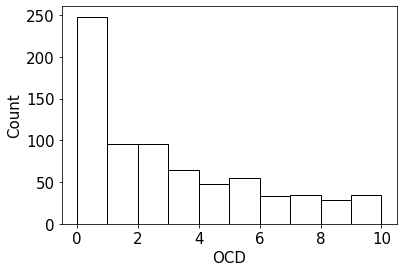

In [62]:
sns.histplot(df_main["OCD"],bins=10,color="white")
plt.show()

In [82]:
df_age = df_main[["Anxiety","Depression","OCD","Age"]].copy()
df_age["CATE"] = pd.cut(df_age["Age"].tolist(),list(range(0, 100, 10)))

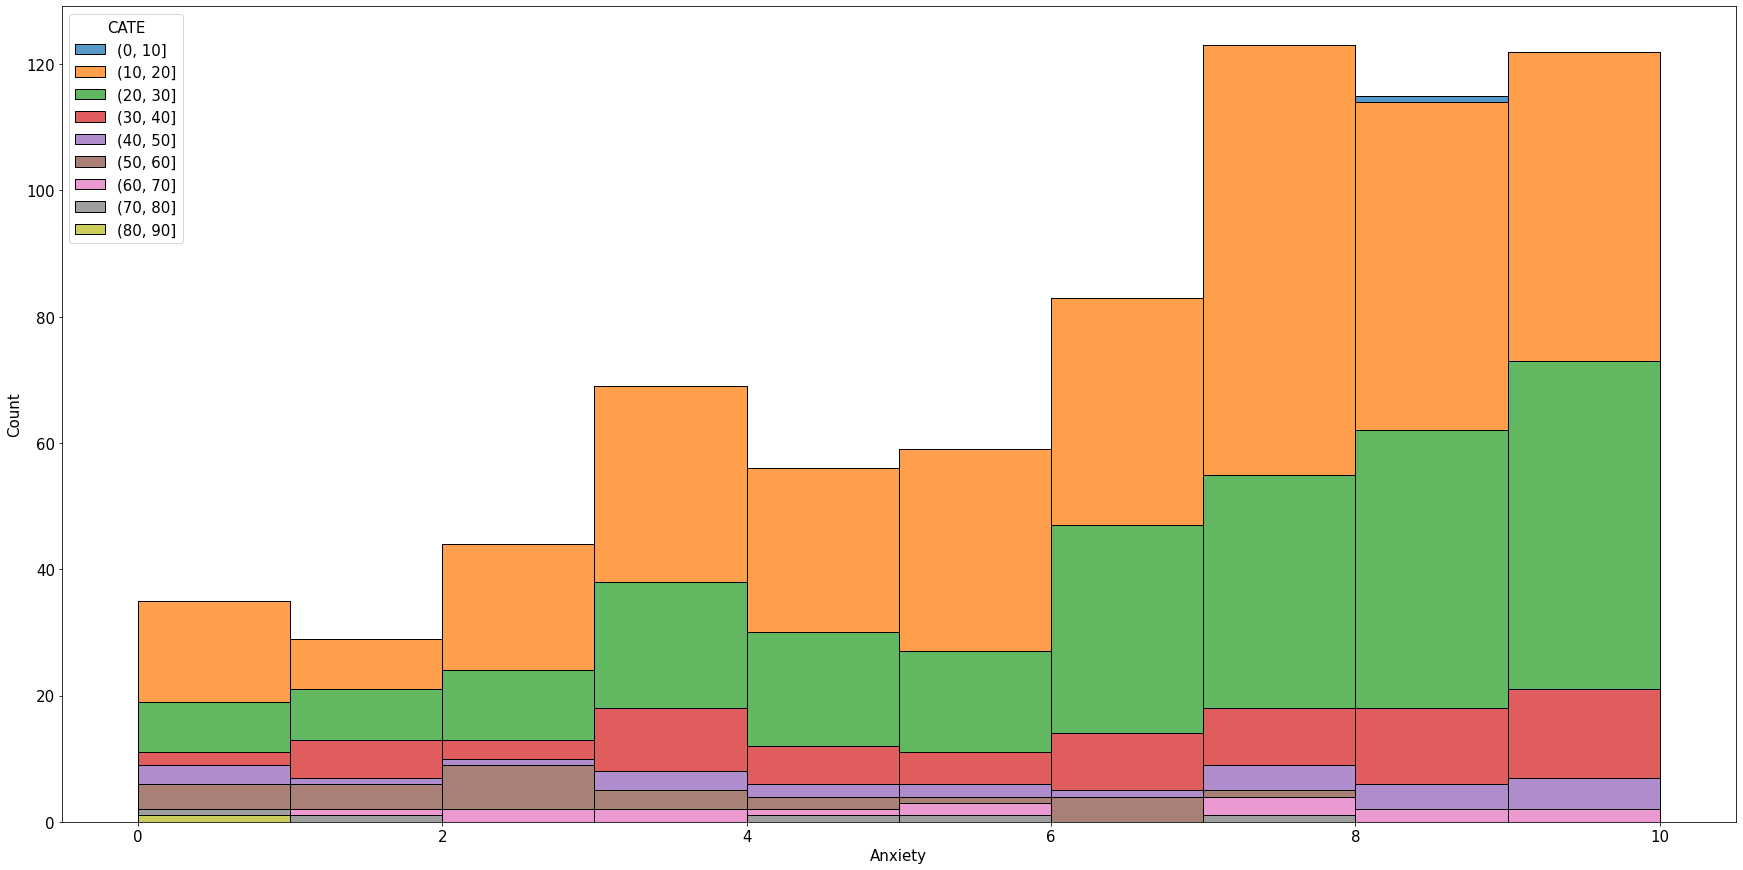

In [64]:
#Anxiety severity by age group
plt.figure(figsize=(30, 15))
sns.histplot(df_age, x="Anxiety",bins=10,hue="CATE", multiple="stack")
plt.show()

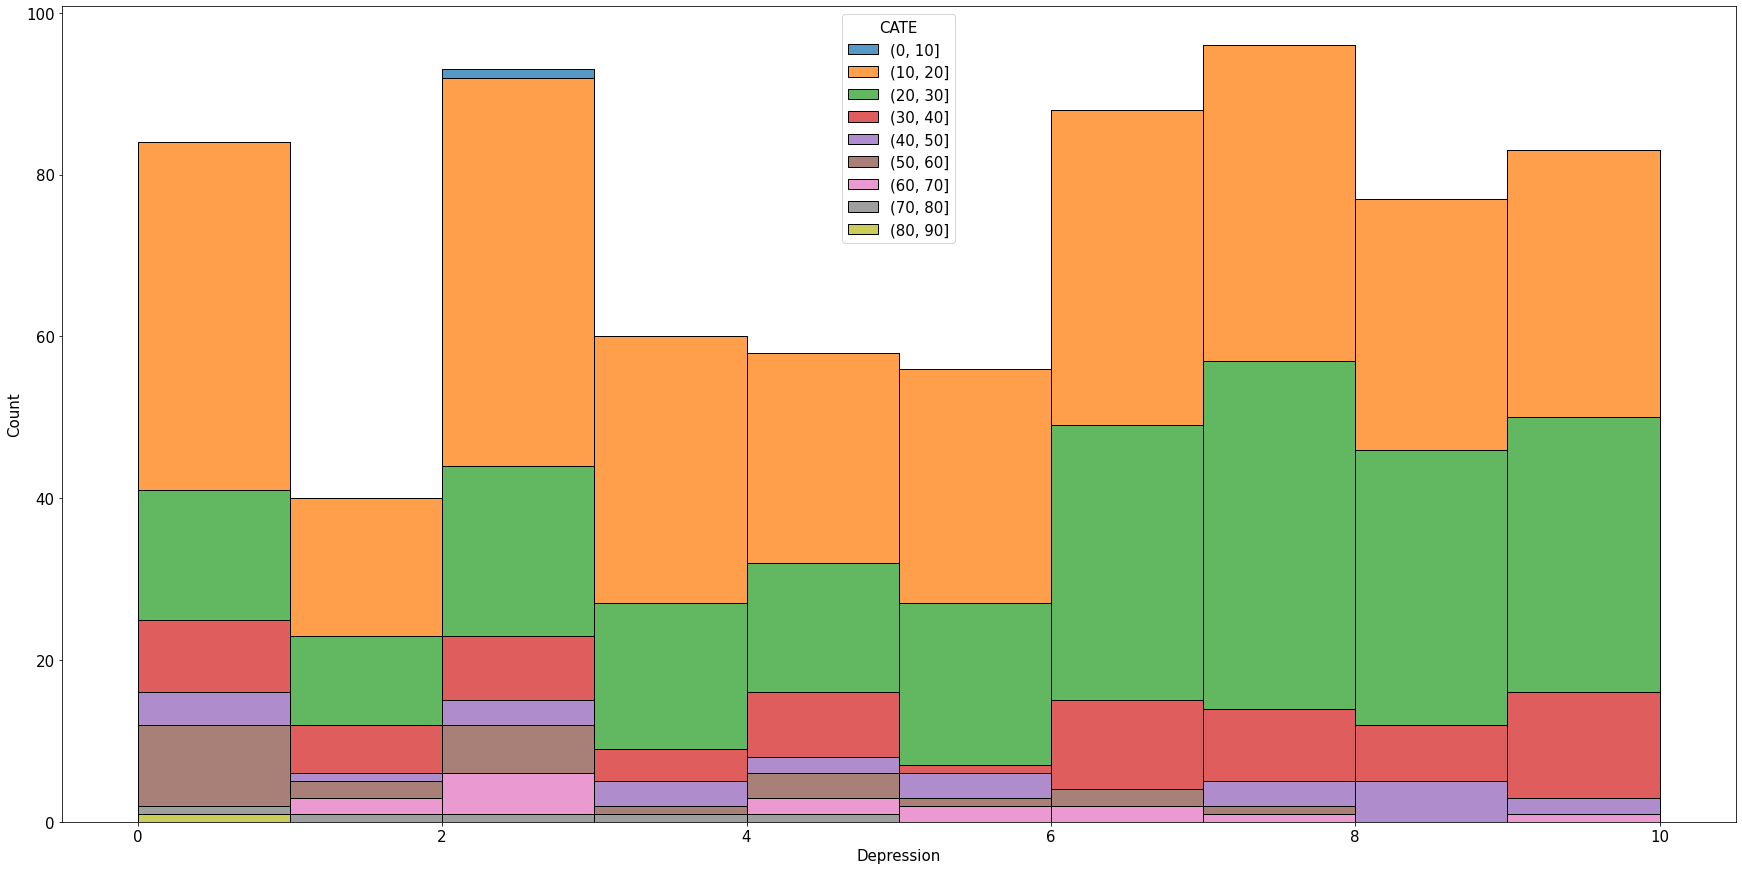

In [65]:
#Depression severity by age group
plt.figure(figsize=(30, 15))
sns.histplot(df_age, x="Depression",bins=10,hue="CATE", multiple="stack")
plt.show()

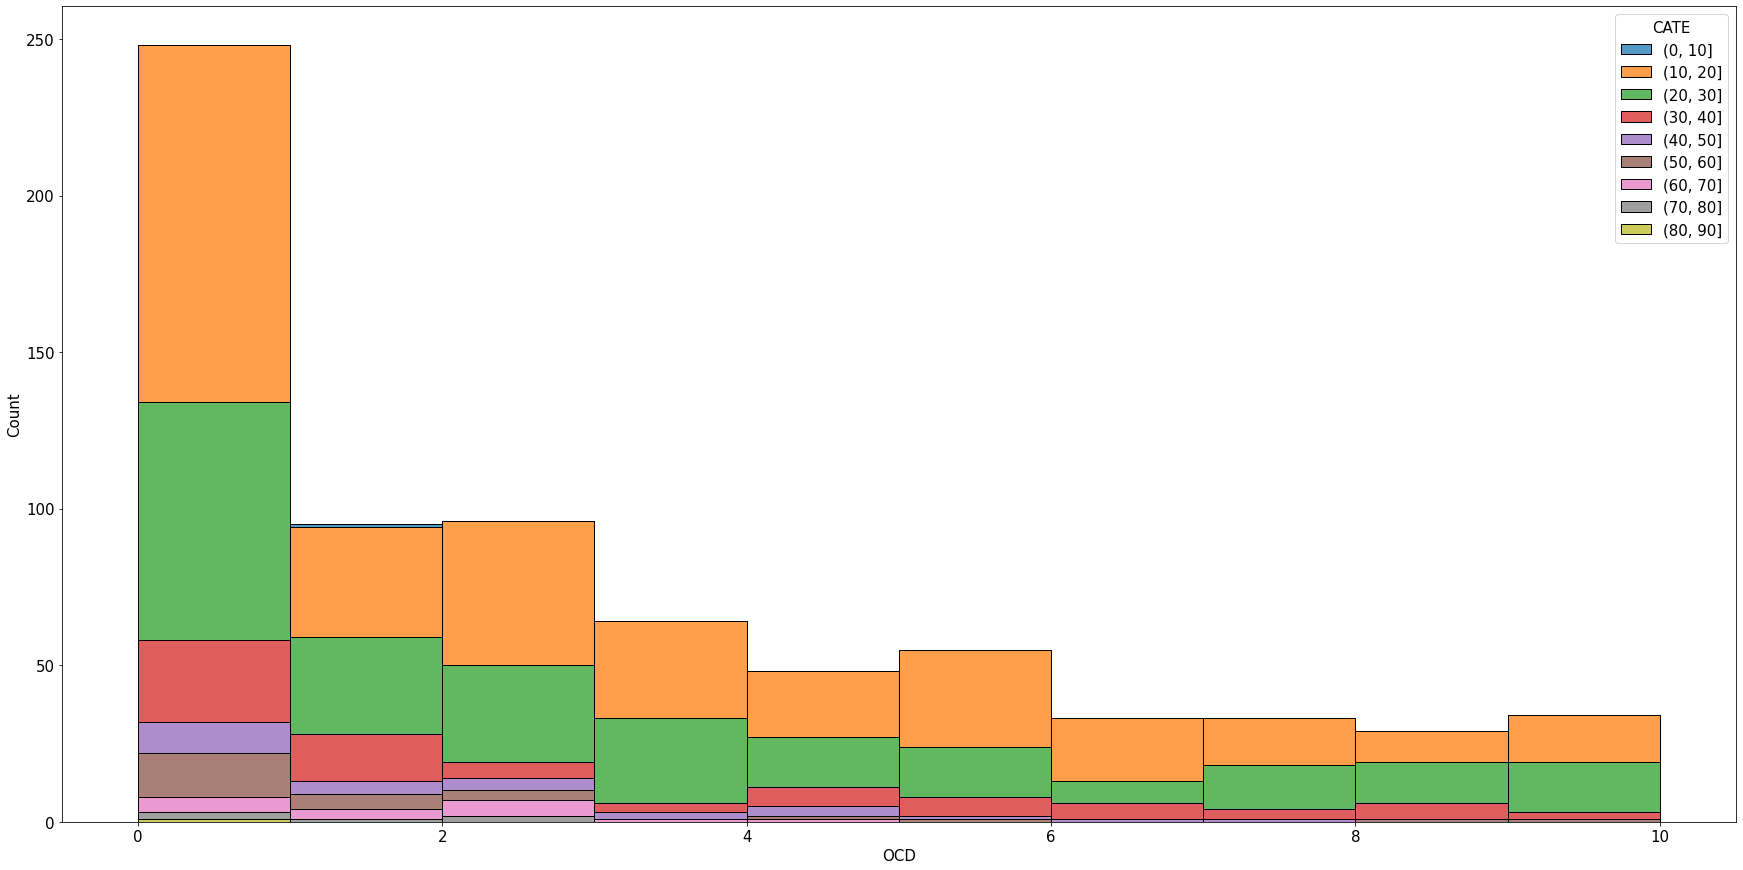

In [66]:
#Severity of obsessive-compulsive disorder by age group
plt.figure(figsize=(30, 15))
sns.histplot(df_age, x="OCD",bins=10,color="#4F81BD",hue="CATE", multiple="stack")
plt.show()

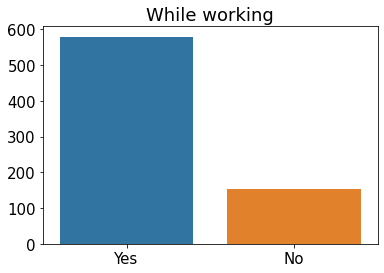

In [67]:
sns.countplot(x="While working", data=df_main).set(title = "While working",xlabel=None,ylabel=None)
plt.show()

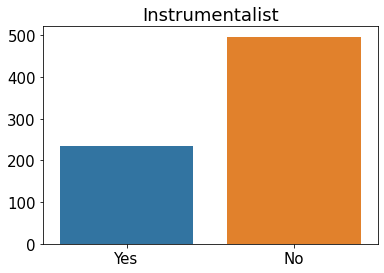

In [68]:
sns.countplot(x="Instrumentalist", data=df_main).set(title = "Instrumentalist",xlabel=None,ylabel=None)
plt.show()

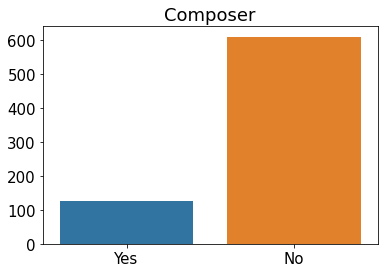

In [69]:
sns.countplot(x="Composer", data=df_main).set(title = "Composer",xlabel=None,ylabel=None)
plt.show()

In [88]:
genrelist = pd.DataFrame(index=[], columns=["Name","Count"])
for i in df_main["Fav genre"].unique():  
    genrelist = genrelist.append(pd.DataFrame([[i,df_main["Fav genre"][df_main["Fav genre"] == i].count()]], columns=["Name","Count"]))
genrelist.sort_values(by="Count",inplace=True,ascending=False)

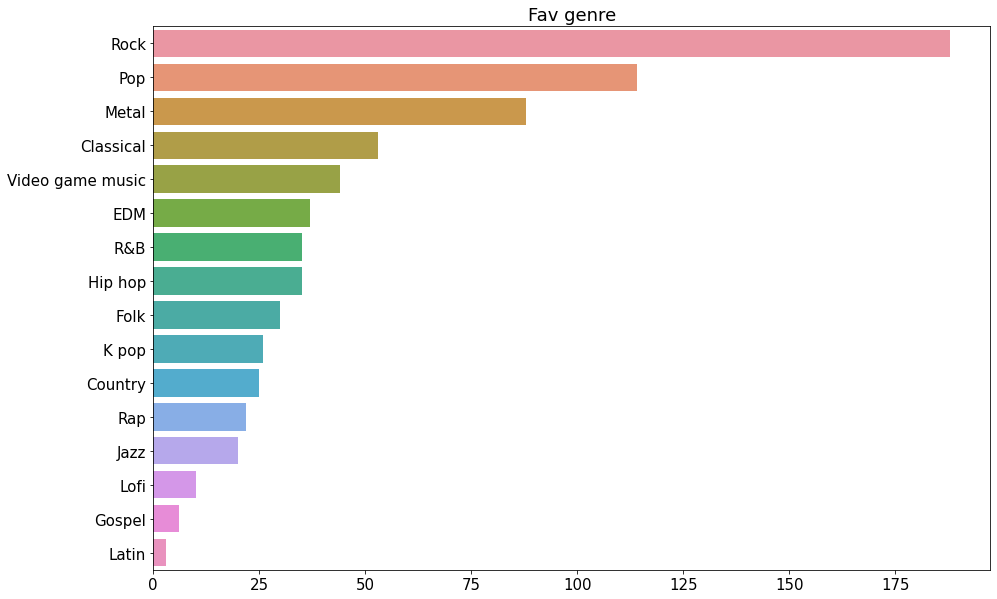

In [89]:
#preferred music trends
plt.figure(figsize=(15, 10))
sns.barplot(x=genrelist.Count, y=list(genrelist.Name), data=genrelist).set(title = "Fav genre",xlabel=None,ylabel=None)
plt.show()

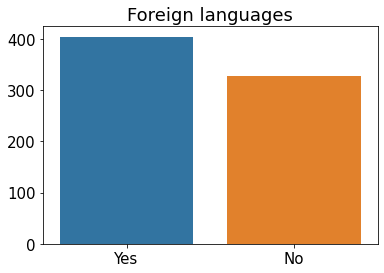

In [72]:
sns.countplot(x="Foreign languages", data=df_main).set(title = "Foreign languages",xlabel=None,ylabel=None)
plt.show()

In [73]:
data = df_main["Primary streaming service"].value_counts()
labels = list(df_main["Primary streaming service"].dropna().unique())
colors = sns.color_palette('bright')

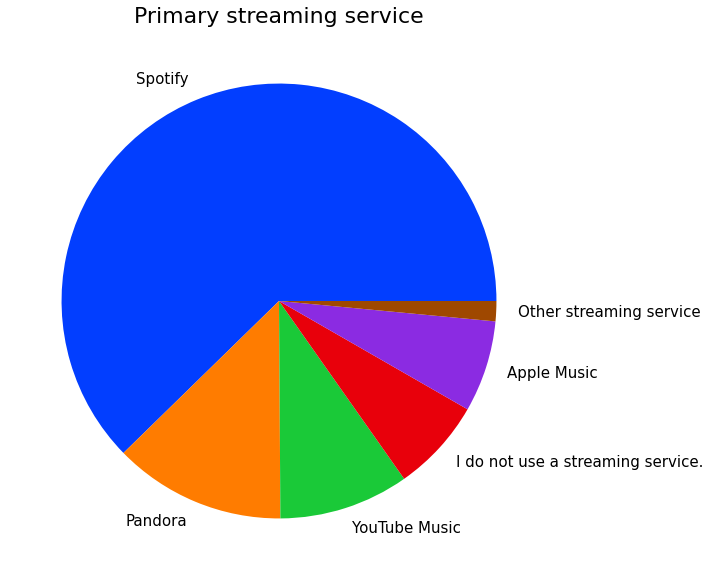

In [81]:
plt.figure(figsize=(10, 10))
plt.title("Primary streaming service",fontsize = 22)
plt.pie(data, labels=labels,colors = colors)
plt.show()